# Paso 4: Análisis Exploratorio de Datos

En este paso analizaremos dos datasets extraídos de la base de datos de Zuber:

El objetivo es entender la distribución del mercado entre compañías y barrios,
identificar los 10 barrios con más finalizaciones y visualizar los hallazgos.

In [14]:
# importamos librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [15]:
# Cargamos los datos
df_companies = pd.read_csv('project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('project_sql_result_04.csv')

In [16]:
#Hacemos una exploración inicial de los datos
# Empezamos con el DataFrame de companies
print(df_companies.head())
print()
print(df_companies.info())
print()
print(df_companies.describe())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 2.5 KB
None

       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000


In [17]:
# Seguimos con el DataFrame que creamos para neighborhoods
print(df_neighborhoods.head())
print()
print(df_neighborhoods.info())
print()
print(df_neighborhoods.describe())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 2.6 KB
None

       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667


In [18]:
# Imprimimos el top 10 barrios por finalizaciones de recorridos
top10_neighborhoods = (df_neighborhoods
                       .sort_values('average_trips', ascending=False)
                       .head(10))
print("\nTop 10 barrios:\n", top10_neighborhoods)


Top 10 barrios:
   dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


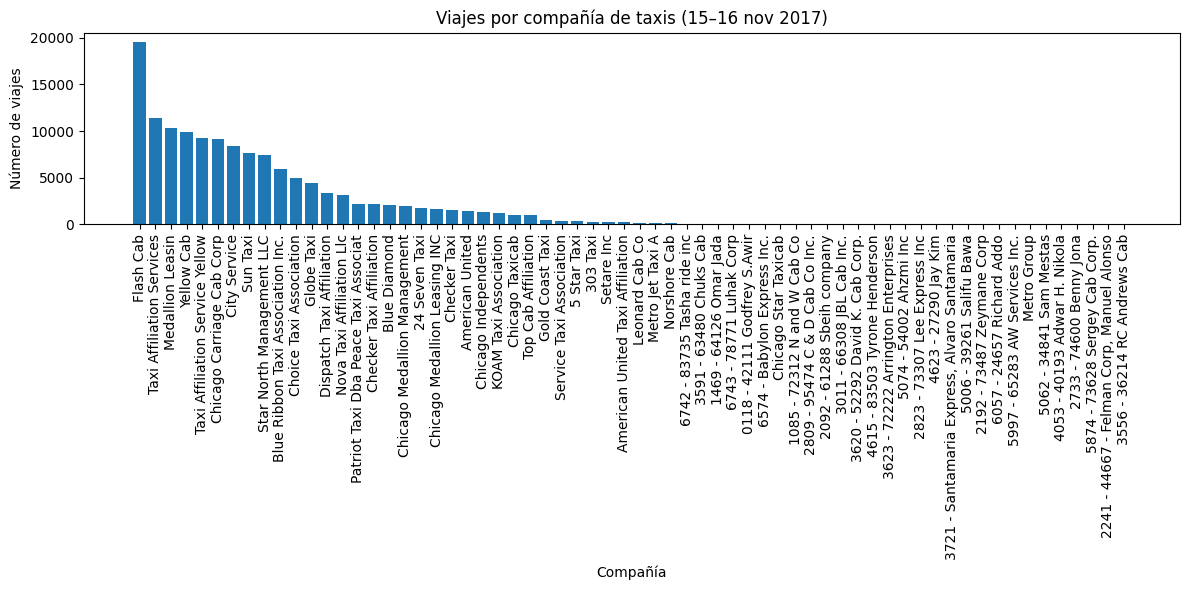

In [19]:
# 1er gráfico: Número de viajes por compañías de taxi
# Creamos un gráfico de barras con pyplot
df_companies_sorted = df_companies.sort_values('trips_amount', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_companies_sorted['company_name'],
       df_companies_sorted['trips_amount']
)
ax.set_title('Viajes por compañía de taxis (15–16 nov 2017)', fontsize=12)
ax.set_xlabel('Compañía')
ax.set_ylabel('Número de viajes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

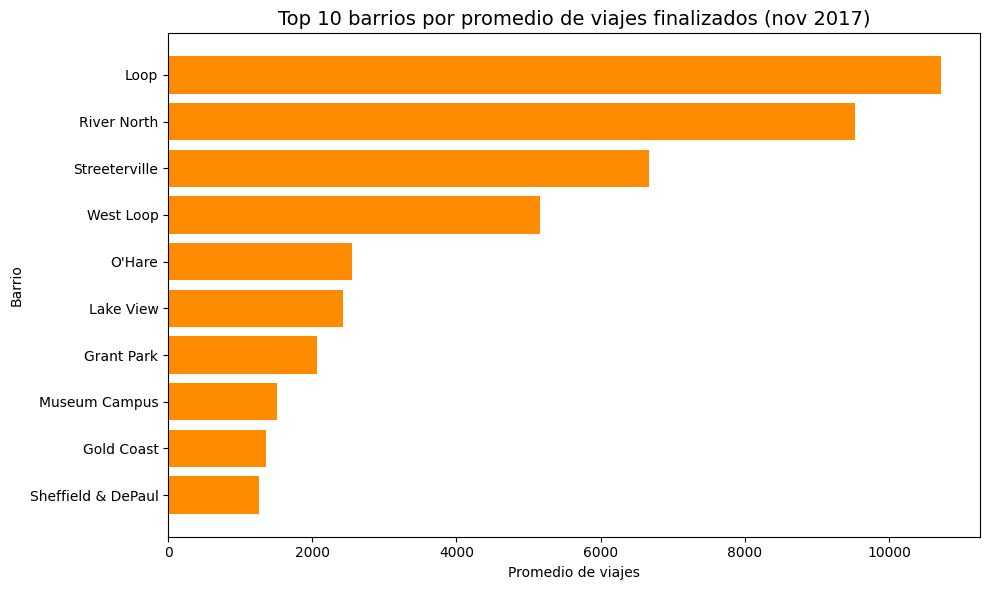

In [20]:
# Gráfico 2: Top 10 de barrios por # de finalizaciones
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_neighborhoods['dropoff_location_name'],
        top10_neighborhoods['average_trips'],
        color='darkorange')
ax.set_title('Top 10 barrios por promedio de viajes finalizados (nov 2017)', fontsize=14)
ax.set_xlabel('Promedio de viajes')
ax.set_ylabel('Barrio')
ax.invert_yaxis()
plt.tight_layout()
plt.show()



## Conclusiones de gráficos y explicación de resultados

- El mercado de taxis en Chicago está altamente concentrado principalmente en 1 compañía (Flash Cab) El segundo en participación es "Taxi Affiliation Services". Mientras la mayoría de compañías tienen participaciones menores.
- Existe una fuete dispersión entre el resto de compañías después de la predominancia mencionada por parte de Flsh Cab, habiendo más de 20 compañías cuya participación se reduce de manera gradual hasta límites marginales en las de más baja participación. Esto por supuesto habla de la flota disponible para operar por parte de cada una de las empresas
- Entre los barrios de finalización, el river North y el Aeropuerto O'Hare destacan como destinos principales, lo que refleja la fuerte demanda en el centro de negocios y el tráfico aeroportuario, como es habitual en las grandes ciudades o, al menos, centros de comercio.
- Los tipos de datos son correctos tras la verificación; no se encontraron valores nulos en ninguno de los dos datasets.


## Paso 5: Prueba de hipótesis

**Hipótesis a probar:**
"La duración promedio de los viajes desde el Loop hasta O'Hare cambia los sábados lluviosos."

**Hipótesis nula (H0):** La duración promedio de los viajes los sábados con clima "Bad" es igual a la duración promedio los sábados con clima "Good".

**Hipótesis alternativa (H1):** La duración promedio de los viajes los sábados con clima "Bad" es diferente a la duración promedio los sábados con clima "Good" (prueba de dos colas).

**Criterio:** Usamos la prueba t de Student para muestras independientes (`scipy.stats.ttest_ind`) porque comparamos las medias de dos grupos independientes (Bad vs Good), asumiendo que la duración de los viajes sigue una distribución aproximadamente normal.

Establecemos alfa = 0.05 como nivel de significación estándar.

In [21]:
# Cargamos los datos de este nuevo DataSet
df_trips = pd.read_csv('project_sql_result_07.csv')

In [22]:
# exploramos los datos
print(df_trips.head())
print()
print(df_trips.info())
print()
print(df_trips['weather_conditions'].value_counts())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0

<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   str    
 1   weather_conditions  1068 non-null   str    
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), str(2)
memory usage: 49.0 KB
None

weather_conditions
Good    888
Bad     180
Name: count, dtype: int64


In [23]:
# Separaramos los grupos
bad_weather  = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']

print(f"Viajes con clima Bad:  {len(bad_weather)}")
print(f"Viajes con clima Good: {len(good_weather)}")
print(f"\nDuración media Bad:  {bad_weather.mean():.1f} seg")
print(f"Duración media Good: {good_weather.mean():.1f} seg")

Viajes con clima Bad:  180
Viajes con clima Good: 888

Duración media Bad:  2427.2 seg
Duración media Good: 1999.7 seg


In [24]:
# Prueba t de Student (dos colas)
alpha = 0.05

t_stat, p_value = stats.ttest_ind(bad_weather, good_weather, equal_var=False)

print(f"\nEstadístico t: {t_stat:.4f}")
print(f"p-value:       {p_value:.4f}")

if p_value < alpha:
    print(f"\nResultado: Se RECHAZA H0 (p={p_value:.4f} < α={alpha})")
    print("La duración promedio SÍ cambia significativamente en sábados lluviosos.")
else:
    print(f"\nResultado: No se rechaza H0 (p={p_value:.4f} >= α={alpha})")
    print("No hay evidencia suficiente para afirmar que la duración cambia.")


Estadístico t: 7.1860
p-value:       0.0000

Resultado: Se RECHAZA H0 (p=0.0000 < α=0.05)
La duración promedio SÍ cambia significativamente en sábados lluviosos.


### Conclusiones del Paso 5

- Se usó la prueba t de Welch (`equal_var=False`) porque no podemos asumir
  varianzas iguales entre ambos grupos sin verificarlo previamente.
- La prueba es de dos colas porque la hipótesis alternativa solo plantea
  que la duración cambia, sin especificar si aumenta o disminuye.
- Con α = 0.05, si p-value < 0.05 concluimos que el clima lluvioso
  tiene un efecto estadísticamente significativo en la duración de los viajes. En este caso, el resultado es de 0.0000, dicho esto, rechazamos la hipótesis nula que afirma que la duración de los viajes en sábados lluviosos es igual a sábados con buen clima